# Compositional inference from repeated experiments

Suppose several experiments probe the same physical system. Each experiment is expensive to simulate, but all experiments share one parameter vector $\theta$. A conventional amortized posterior trained on $J$ experiments at once would require $J$ simulator calls for every training example and would be tied to that choice of $J$.

Compositional inference avoids this fixed panel. We train a diffusion posterior on **one experiment at a time**,

$$q_\phi(\theta\mid y_j),$$

and combine independently collected experiments only when data are observed. Conditional independence gives

$$p(\theta\mid y_{1:J}) \propto p(\theta)^{1-J}\prod_{j=1}^J p(\theta\mid y_j).$$

A diffusion model represents each posterior through its score. Products of densities become sums of scores, while the factor $p(\theta)^{1-J}$ prevents the prior from being counted $J$ times. One trained network can therefore combine two experiments or twenty without retraining.

This notebook isolates that idea. A small FitzHugh--Nagumo neuron receives different input currents. Every voltage trace is an independent experiment with the same two biophysical parameters. There are no subject-level parameters, no population distribution, and no ancestral sampling. We will:

1. train on individual voltage traces;
2. compose $1$, $2$, $4$, and $8$ traces;
3. compare the eight-trace result with the exact posterior on a grid.

> **Assumption.** The traces must be conditionally independent given $\theta$ and their known input currents. Duplicating one trace would count the same evidence twice and produce an overconfident posterior.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import bayesflow as bf

N_TRAIN = 256
N_VALIDATION = 128
EPOCHS = 2
N_POSTERIOR_SAMPLES = 32
INTEGRATION_STEPS = 8


INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.


INFO:bayesflow:Using backend 'jax'


## One simulator call, one experiment

The FitzHugh--Nagumo equations provide a compact model of excitable voltage dynamics:

$$\dot v = v - \frac{v^3}{3} - w + I, \qquad
\dot w = \frac{v + a - bw}{\tau}.$$

We infer the excitability parameter $a$ and the log time scale $\log\tau$; $b$ is fixed. The applied current $I_j$ is known and may differ between experiments. The observed voltage has independent Gaussian measurement noise:

$$y_j(t) = v(t;\theta,I_j) + \epsilon_j(t), \qquad
\epsilon_j(t)\sim\mathcal N(0,\sigma_y^2).$$

The network receives two channels: voltage and the applied current repeated along the time axis. Supplying the experimental setting is essential; otherwise a change in stimulus could be mistaken for a change in the neuron.

We use a Gaussian prior in the coordinates learned by the network. This keeps the prior score analytic and avoids parameter transforms inside the compositional sampler.


In [2]:
TIME = np.linspace(0.0, 40.0, 161, dtype=np.float32)
DT = TIME[1] - TIME[0]
B = 0.8
NOISE_SD = 0.12
CURRENT_LOW = 0.4
CURRENT_HIGH = 1.1

PRIOR_MEAN = np.array([0.70, np.log(12.5)], dtype=np.float32)
PRIOR_SD = np.array([0.08, 0.18], dtype=np.float32)

training_rng = np.random.default_rng(2026)
validation_rng = np.random.default_rng(2027)
test_rng = np.random.default_rng(2028)


In [3]:
def sample_prior(n_simulations, rng):
    noise = rng.standard_normal((n_simulations, 2), dtype=np.float32)
    return PRIOR_MEAN + PRIOR_SD * noise


def simulate_voltage(parameters, currents):
    """Euler simulation for a batch of parameter-current pairs."""
    a = parameters[:, 0]
    tau = np.exp(parameters[:, 1])
    voltage = np.empty((parameters.shape[0], TIME.size), dtype=np.float32)
    recovery = np.empty_like(voltage)
    voltage[:, 0] = -1.0
    recovery[:, 0] = 1.0

    for step in range(TIME.size - 1):
        v = voltage[:, step]
        w = recovery[:, step]
        voltage[:, step + 1] = v + DT * (v - v**3 / 3.0 - w + currents)
        recovery[:, step + 1] = w + DT * (v + a - B * w) / tau

    return voltage


def observe(parameters, currents, rng):
    voltage = simulate_voltage(parameters, currents)
    noise = NOISE_SD * rng.standard_normal(voltage.shape, dtype=np.float32)
    observables = np.empty(voltage.shape + (2,), dtype=np.float32)
    observables[..., 0] = voltage + noise
    observables[..., 1] = currents[:, None]
    return observables


def simulate_dataset(n_simulations, rng):
    parameters = sample_prior(n_simulations, rng)
    unit_uniform = rng.random(n_simulations, dtype=np.float32)
    currents = CURRENT_LOW + (CURRENT_HIGH - CURRENT_LOW) * unit_uniform
    return {
        "parameters": parameters,
        "observables": observe(parameters, currents, rng),
    }


## The observations to be composed

For the demonstration, we fix one parameter vector and perform eight experiments at different currents. The traces have independent measurement noise. During training the network will never see such an eight-experiment panel: it sees only individual rows with shape `(time, channels)`.


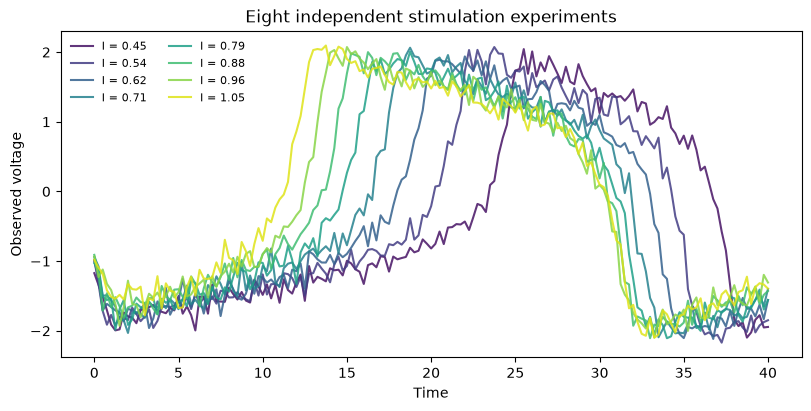

In [4]:
TRUE_PARAMETERS = np.array([0.72, np.log(11.5)], dtype=np.float32)
TEST_CURRENTS = np.linspace(0.45, 1.05, 8, dtype=np.float32)
parameter_panel = np.repeat(TRUE_PARAMETERS[None, :], TEST_CURRENTS.size, axis=0)
observed_panel = observe(parameter_panel, TEST_CURRENTS, test_rng)

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
colors = plt.cm.viridis(np.linspace(0.05, 0.95, TEST_CURRENTS.size))

for experiment, current, color in zip(observed_panel, TEST_CURRENTS, colors):
    ax.plot(TIME, experiment[:, 0], color=color, alpha=0.85, label=f"I = {current:.2f}")

ax.set(xlabel="Time", ylabel="Observed voltage", title="Eight independent stimulation experiments")
ax.legend(ncol=2, fontsize=8, frameon=False)


## Train one local posterior

Each training pair contains one parameter draw and one voltage trace. The time-series network compresses the trace, and the diffusion model learns the local posterior score. Training on a single experiment is the only amortization step; composition does not fit another model.

The deliberately small network and training configuration keep the notebook quick to run. Increase the constants in the first code cell for a serious fit.


In [5]:
training_data = simulate_dataset(N_TRAIN, training_rng)
validation_data = simulate_dataset(N_VALIDATION, validation_rng)

workflow = bf.CompositionalWorkflow(
    inference_variables="parameters",
    summary_variables="observables",
    summary_network=bf.networks.TimeSeriesNetwork(
        summary_dim=8,
        filters=(16, 32),
        kernel_sizes=(5, 3),
        strides=(1, 1),
        recurrent_dim=32,
        skip_steps=2,
        dropout=0.0,
    ),
    inference_network=bf.networks.DiffusionModel(
        subnet_kwargs={"widths": (64, 64)},
        integrate_kwargs={"method": "euler", "steps": INTEGRATION_STEPS},
    ),
    standardize="all",
)

history = workflow.fit_offline(
    training_data,
    validation_data=validation_data,
    epochs=EPOCHS,
    batch_size=128,
)


INFO:bayesflow:Fitting on dataset instance of OfflineDataset.


INFO:bayesflow:Building on a test batch.


Epoch 1/2


1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.7256

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.6552

...

Epoch 2/2


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.5284

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.5312

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 0.5298 - val_loss: 0.6237


INFO:bayesflow:Training completed in 12.84 seconds.


The loss is a training diagnostic, not a calibration test. Its purpose here is simply to confirm that the local score model is learning from independent experiments.


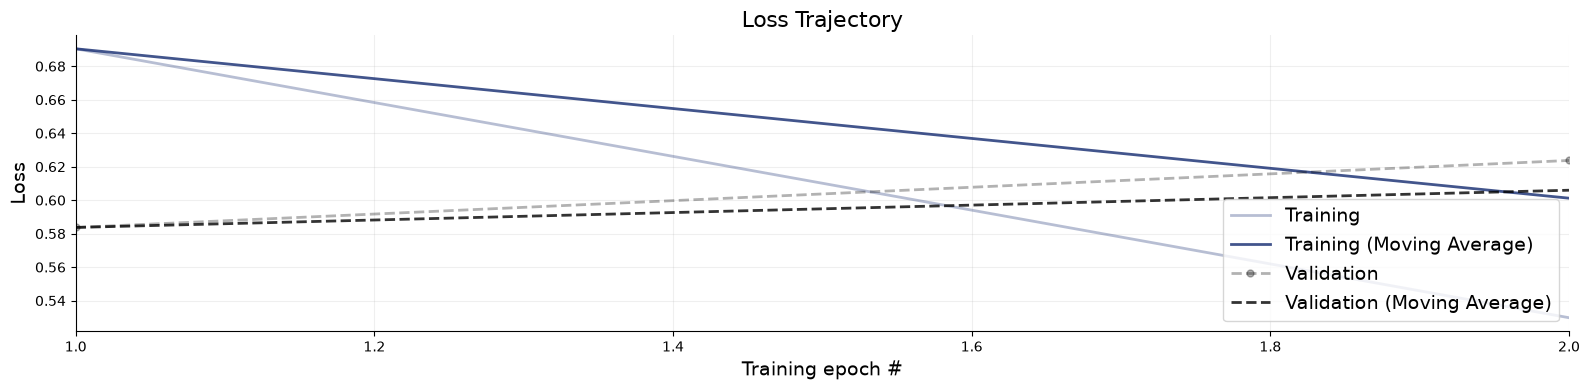

In [6]:
fig = bf.diagnostics.loss(history)


## Add posterior scores, subtract repeated priors

For one experiment we use ordinary posterior sampling. For two or more, `compositional_sample` evaluates the learned score for every trace and combines the results. The function below supplies

$$\nabla_\theta \log p(\theta)
= -\frac{\theta-\mu_0}{\sigma_0^2}$$

for the independent Gaussian prior. BayesFlow handles the coordinate correction introduced by standardization. The condition array has shape `(datasets, experiments, time, channels)`; here there is one dataset and up to eight experiments.


In [7]:
def prior_score(variables):
    parameters = variables["parameters"]
    return {"parameters": -(parameters - PRIOR_MEAN) / PRIOR_SD**2}


posterior_by_experiment_count = {
    1: workflow.sample(
        conditions={"observables": observed_panel[None, 0]},
        num_samples=N_POSTERIOR_SAMPLES,
        seed=301,
    )["parameters"][0]
}

for n_experiments in (2, 4, 8):
    posterior_by_experiment_count[n_experiments] = workflow.compositional_sample(
        conditions={"observables": observed_panel[None, :n_experiments]},
        num_samples=N_POSTERIOR_SAMPLES,
        compute_prior_score=prior_score,
        mini_batch_size=n_experiments,
        seed=300 + n_experiments,
    )["parameters"][0]


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.32 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 1.97 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.09 seconds.


Every panel below comes from the same trained network. Only the number of score terms changes. With adequate training, the posterior should move toward the true parameters and contract as independent experiments are added. The tiny defaults above demonstrate the mechanics and figures, but they are intentionally insufficient for inferential conclusions.


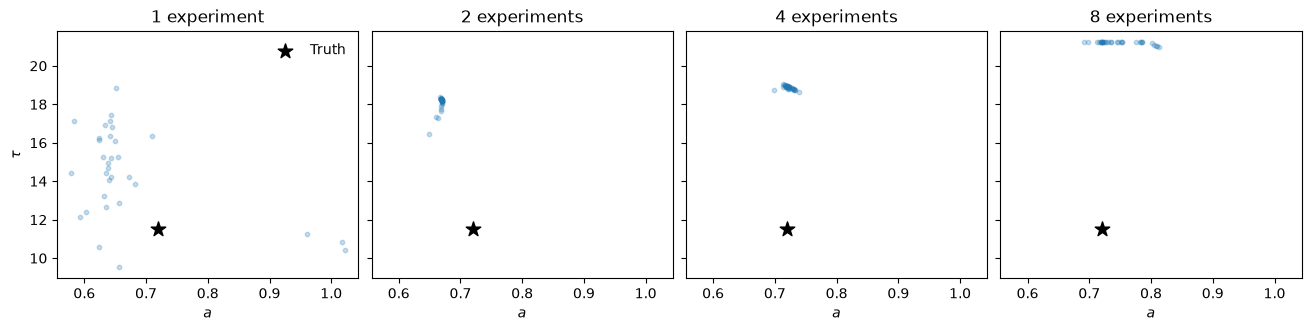

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharex=True, sharey=True, layout="constrained")
for ax, (n_experiments, samples) in zip(axes, posterior_by_experiment_count.items()):
    ax.scatter(samples[:, 0], np.exp(samples[:, 1]), s=10, alpha=0.25)
    ax.scatter(TRUE_PARAMETERS[0], np.exp(TRUE_PARAMETERS[1]), marker="*", s=120, color="black", label="Truth")
    ax.set_title(f"{n_experiments} experiment{'s' if n_experiments > 1 else ''}")
    ax.set_xlabel(r"$a$")
axes[0].set_ylabel(r"$\tau$")
axes[0].legend(frameon=False)


## Check against the exact posterior

The Gaussian observation model makes the likelihood available here, although the diffusion model never evaluates it. Because $\theta$ is two-dimensional, a grid gives a transparent reference:

$$\log p(\theta\mid y_{1:J}) = \log p(\theta)
- \frac{1}{2\sigma_y^2}\sum_{j,t}
\left[y_j(t)-v(t;\theta,I_j)\right]^2 + C.$$

This reference is included to test composition, not because compositional SBI requires a tractable likelihood. In an expensive simulator such as HNN, the same workflow would be useful precisely because this grid calculation is unavailable or prohibitive.


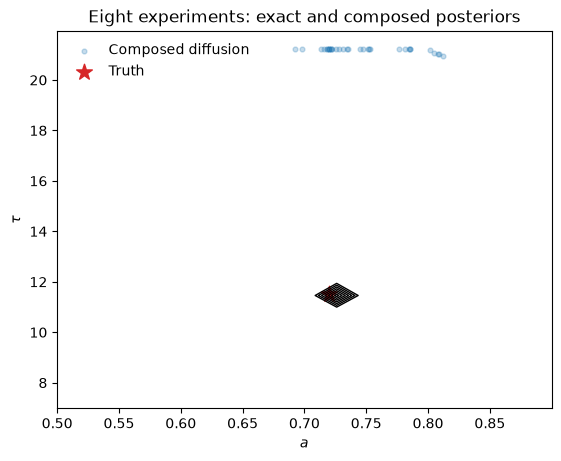

In [9]:
grid_size = 24
a_values = np.linspace(0.50, 0.90, grid_size, dtype=np.float32)
log_tau_values = np.linspace(np.log(7.0), np.log(18.0), grid_size, dtype=np.float32)
a_grid, log_tau_grid = np.meshgrid(a_values, log_tau_values)
grid_parameters = np.column_stack((a_grid.ravel(), log_tau_grid.ravel()))

standardized_grid = (grid_parameters - PRIOR_MEAN) / PRIOR_SD
log_posterior = -0.5 * np.sum(standardized_grid**2, axis=1)

for experiment in observed_panel:
    currents = np.full(grid_parameters.shape[0], experiment[0, 1], dtype=np.float32)
    predicted_voltage = simulate_voltage(grid_parameters, currents)
    residual = experiment[:, 0] - predicted_voltage
    log_posterior -= np.sum(residual**2, axis=1) / (2.0 * NOISE_SD**2)

reference_density = np.exp(log_posterior - np.max(log_posterior)).reshape(a_grid.shape)
composed_samples = posterior_by_experiment_count[8]

fig, ax = plt.subplots(figsize=(5.5, 4.5), layout="constrained")
ax.contour(a_grid, np.exp(log_tau_grid), reference_density, levels=8, colors="black", linewidths=1.0)
ax.scatter(composed_samples[:, 0], np.exp(composed_samples[:, 1]), s=12, alpha=0.25, label="Composed diffusion")
ax.scatter(TRUE_PARAMETERS[0], np.exp(TRUE_PARAMETERS[1]), marker="*", s=140, color="tab:red", label="Truth")
ax.set(xlabel=r"$a$", ylabel=r"$\tau$", title="Eight experiments: exact and composed posteriors")
ax.legend(frameon=False)


## What composition bought us

The training set contained exactly one simulation per parameter draw. At inference time, the same local score model used an arbitrary number of experiments without a second network or a hierarchical latent-variable model. The simulation saving becomes substantial when one forward run is expensive: training a fixed eight-experiment amortizer would require roughly eight times as many forward simulations per parameter draw.

The construction also states its limits clearly:

- experiments must be conditionally independent given the shared parameters and known settings;
- the prior correction is part of the posterior identity, not an optional calibration trick;
- adding experiments does not repair a poorly trained local score model, and score errors may accumulate;
- posterior recovery and calibration should be checked over many simulated datasets before scientific use.

A direct HNN extension would let repeated trials or stimulation protocols share HNN parameters and treat each waveform as one compositional item. A lightweight hierarchical extension could instead draw one varying HNN parameter per subject and infer only its population mean and scale. Recovering every local parameter would reintroduce the two-workflow complexity intentionally omitted here.
